In [1]:
!pip install tensorflow keras scikit-learn seaborn -q


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


## 1. Imports & GPU Setup

In [2]:
import os

# Disable XLA autotuner — prevents multi-minute hang on first forward pass
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'

import time
import json
import inspect
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

import tensorflow as tf
import keras
from keras import layers, Model, regularizers
from keras.applications import EfficientNetV2S
from keras.applications.efficientnet_v2 import preprocess_input
from keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# -- GPU setup (same as v1.1) --
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

# -- Mixed precision: ~30% faster on RTX 3060 Ti, halves activation memory --
# tf.keras.mixed_precision.set_global_policy('mixed_float16')

!nvidia-smi
print(f'TF  : {tf.__version__}')
print(f'GPU : {tf.config.list_physical_devices("GPU")}')
print(f'Policy: {tf.keras.mixed_precision.global_policy()}')

2026-05-31 10:14:49.154922: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780222489.597923    4252 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780222489.687174    4252 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-31 10:14:50.247311: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Sun May 31 10:14:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.52.01              Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 Ti     On  |   00000000:06:00.0  On |                  N/A |
|  0%   42C    P8             20W /  220W |    6487MiB /   8192MiB |     39%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Config

In [3]:
MODEL_NAME = 'EfficientNetV2S_2.1'
BASE_DIR   = '/tf/data/models'
SAVE_DIR   = f'{BASE_DIR}/{MODEL_NAME}'
os.makedirs(SAVE_DIR, exist_ok=True)

# -- Data paths --
DATA_ROOT    = '/tf/data/food-mm'       # root of downloaded images
TRAIN_DIR    = f'{DATA_ROOT}/train'
VAL_DIR      = f'{DATA_ROOT}/val'
LABEL_MAP    = '/tf/data/output/label_map.json'
TRAIN_CSV    = '/tf/data/output/train.csv'
VAL_CSV      = '/tf/data/output/val.csv'
NUT_STATS    = '/tf/data/output/nutrition_stats.json'

# -- Training --
IMG_SIZE          = (384, 384)
BATCH_SIZE        = 32
FINE_TUNE_BATCH_SIZE = 16
EPOCHS            = 60
FINE_TUNE_EPOCHS  = 20
AUTOTUNE          = tf.data.AUTOTUNE

# -- Multi-task loss weights --
CLS_LOSS_WEIGHT   = 2.0    # classification (increased: 8x dominance over nutrition)
NUT_LOSS_WEIGHT   = 0.25   # nutrition regression (reduced to de-prioritize)

# -- Load label map --
with open(LABEL_MAP) as f:
    idx_to_class = json.load(f)           # {'0': 'Beef Noodles', ...}

N_CLASSES    = len(idx_to_class)
N_class      = {int(k): v for k, v in idx_to_class.items()}
class_N      = {v: k for k, v in N_class.items()}

print(f'N_CLASSES : {N_CLASSES}')
print(f'Sample    : {list(N_class.items())[:5]}')

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)

# -- Nutrition columns & normalisation --
NUT_COLS = ['calories', 'protein', 'fat', 'carbs']

with open(NUT_STATS) as f:
    _nut_stats = json.load(f)

_nut_min   = np.array([_nut_stats[c]['min'] for c in NUT_COLS], dtype=np.float32)
_nut_max   = np.array([_nut_stats[c]['max'] for c in NUT_COLS], dtype=np.float32)
_nut_range = np.where(_nut_max - _nut_min > 0, _nut_max - _nut_min, 1.0)

def normalize_nutrition(raw: np.ndarray) -> np.ndarray:
    return np.clip((raw - _nut_min) / _nut_range, 0.0, 1.0)

def denormalize_nutrition(norm: np.ndarray) -> np.ndarray:
    return norm * _nut_range + _nut_min

print(f'NUT_COLS : {NUT_COLS}')
print(f'Nut min  : {_nut_min}')
print(f'Nut max  : {_nut_max}')

# Compute median nutrition per label from training set
nut_by_label = (
    train_df.groupby('label')[NUT_COLS]
    .median()
    .reset_index()
)

# Dict: label_int -> normalized np.array([cal, protein, fat, carbs])
label_to_nutrition = {}
for _, row in nut_by_label.iterrows():
    raw = np.array([row[c] for c in NUT_COLS], dtype=np.float32)
    label_to_nutrition[int(row['label'])] = normalize_nutrition(raw)

# Fallback for any label not in CSV (shouldn't happen, but safety)
FALLBACK_NUT = normalize_nutrition(np.array([60., 1., 0.3, 15.], dtype=np.float32))

print(f'Nutrition lookup built for {len(label_to_nutrition)} labels')
print('Sample:')
for lbl in list(label_to_nutrition.keys())[:3]:
    print(f'  Label {lbl} ({N_class[lbl]}): {label_to_nutrition[lbl].round(3)}')

N_CLASSES : 388
Sample    : [(0, 'Apple'), (1, 'Apples'), (2, 'Assorted Desserts'), (3, 'Assorted Snacks'), (4, 'Avocado')]
NUT_COLS : ['calories', 'protein', 'fat', 'carbs']
Nut min  : [4.  0.1 0.1 0. ]
Nut max  : [3000.  250.  220.  400.]
Nutrition lookup built for 388 labels
Sample:
  Label 0 (Apple): [0.03  0.002 0.001 0.062]
  Label 1 (Apples): [0.172 0.004 0.004 0.35 ]
  Label 2 (Assorted Desserts): [0.199 0.028 0.09  0.2  ]


In [4]:
# train_df = pd.read_csv(TRAIN_CSV)
# val_df   = pd.read_csv(VAL_CSV)

# # Compute median nutrition per label from training set
# nut_by_label = (
#     train_df.groupby('label')[NUT_COLS]
#     .median()
#     .reset_index()
# )

# # Dict: label_int -> normalized np.array([cal, protein, fat, carbs])
# label_to_nutrition = {}
# for _, row in nut_by_label.iterrows():
#     raw = np.array([row[c] for c in NUT_COLS], dtype=np.float32)
#     label_to_nutrition[int(row['label'])] = normalize_nutrition(raw)

# # Fallback for any label not in CSV (shouldn't happen, but safety)
# FALLBACK_NUT = normalize_nutrition(np.array([60., 1., 0.3, 15.], dtype=np.float32))

# print(f'Nutrition lookup built for {len(label_to_nutrition)} labels')
# print('Sample:')
# for lbl in list(label_to_nutrition.keys())[:3]:
#     print(f'  Label {lbl} ({N_class[lbl]}): {label_to_nutrition[lbl].round(3)}')

In [5]:
# -- Scan directory -> list of (path, label, nutrition_normalized) --
def scan_directory(split_dir, label_to_nutrition, fallback):
    paths, labels, nutritions = [], [], []
    for label_folder in sorted(os.listdir(split_dir), key=lambda x: int(x)):
        label     = int(label_folder)
        folder    = os.path.join(split_dir, label_folder)
        nutrition = label_to_nutrition.get(label, fallback)
        for fname in os.listdir(folder):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                paths.append(os.path.join(folder, fname))
                labels.append(label)
                nutritions.append(nutrition)
    return paths, labels, nutritions

print('Scanning train...')
train_paths, train_labels, train_nuts = scan_directory(TRAIN_DIR, label_to_nutrition, FALLBACK_NUT)
print(f'  {len(train_paths):,} train images')

print('Scanning val...')
val_paths, val_labels, val_nuts = scan_directory(VAL_DIR, label_to_nutrition, FALLBACK_NUT)
print(f'  {len(val_paths):,} val images')

Scanning train...
  268,039 train images
Scanning val...
  84,742 val images


In [6]:
from collections import Counter

# -- Compute per-class sample counts for tier assignment --
label_counts = Counter(train_labels)

tier0 = sum(1 for l in train_labels if label_counts[l] >= 500)
tier1 = sum(1 for l in train_labels if 100 <= label_counts[l] < 500)
tier2 = sum(1 for l in train_labels if label_counts[l] < 100)
print(f'Tier 0 (light  aug, >=500 samples) : {tier0:,} images')
print(f'Tier 1 (medium aug, 100-499)       : {tier1:,} images')
print(f'Tier 2 (heavy  aug, <100 samples)  : {tier2:,} images')

# -- Image loader --
@tf.function
def load_image(path, label, nutrition):
    raw   = tf.io.read_file(path)
    image = tf.image.decode_jpeg(raw, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label, nutrition

# -- Three augmentation levels --
@tf.function
def augment_light(image, label, nutrition):
    """Dominant classes — flip only to preserve clean signal."""
    image = tf.image.random_flip_left_right(image)
    return image, label, nutrition

@tf.function
def augment_medium(image, label, nutrition):
    """Medium classes — standard augmentation."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.05)
    pad_h = int(IMG_SIZE[0] * 0.1)
    pad_w = int(IMG_SIZE[1] * 0.1)
    image = tf.image.pad_to_bounding_box(
        image, pad_h, pad_w,
        IMG_SIZE[0] + 2 * pad_h, IMG_SIZE[1] + 2 * pad_w
    )
    image = tf.image.random_crop(image, size=[IMG_SIZE[0], IMG_SIZE[1], 3])
    return image, label, nutrition

@tf.function
def augment_heavy(image, label, nutrition):
    """Rare classes — aggressive augmentation to compensate low sample count."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.6, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.4)
    image = tf.image.random_hue(image, max_delta=0.1)
    pad_h = int(IMG_SIZE[0] * 0.15)
    pad_w = int(IMG_SIZE[1] * 0.15)
    image = tf.image.pad_to_bounding_box(
        image, pad_h, pad_w,
        IMG_SIZE[0] + 2 * pad_h, IMG_SIZE[1] + 2 * pad_w
    )
    image = tf.image.random_crop(image, size=[IMG_SIZE[0], IMG_SIZE[1], 3])
    return image, label, nutrition

@tf.function
def format_sample(image, label, nutrition):
    image    = preprocess_input(image)
    label_oh = tf.one_hot(label, N_CLASSES)
    return image, {'class_output': label_oh, 'nutrition_output': nutrition}

def make_tier_ds(paths, labels, nutritions, aug_fn):
    ds = tf.data.Dataset.from_tensor_slices((
        tf.constant(paths),
        tf.constant(labels, dtype=tf.int32),
        tf.constant(np.array(nutritions), dtype=tf.float32)
    ))
    ds = ds.shuffle(min(len(paths), 5000), reshuffle_each_iteration=True)
    ds = ds.map(load_image,    num_parallel_calls=AUTOTUNE)
    ds = ds.map(aug_fn,        num_parallel_calls=AUTOTUNE)
    ds = ds.map(format_sample, num_parallel_calls=AUTOTUNE)
    ds = ds.repeat()
    return ds

def build_tiered_dataset(paths, labels, nutritions):
    """Proportional tier weights match the val set's natural class distribution,
    preventing the train/val mismatch caused by equal 1/3 oversampling of rare classes."""
    t0_p, t0_l, t0_n = [], [], []
    t1_p, t1_l, t1_n = [], [], []
    t2_p, t2_l, t2_n = [], [], []

    for p, l, n in zip(paths, labels, nutritions):
        count = label_counts[l]
        if count >= 500:
            t0_p.append(p); t0_l.append(l); t0_n.append(n)
        elif count >= 100:
            t1_p.append(p); t1_l.append(l); t1_n.append(n)
        else:
            t2_p.append(p); t2_l.append(l); t2_n.append(n)

    print(f'  Tier 0 (light)  : {len(t0_p):,} samples')
    print(f'  Tier 1 (medium) : {len(t1_p):,} samples')
    print(f'  Tier 2 (heavy)  : {len(t2_p):,} samples')

    ds0 = make_tier_ds(t0_p, t0_l, t0_n, augment_light)
    ds1 = make_tier_ds(t1_p, t1_l, t1_n, augment_medium)
    ds2 = make_tier_ds(t2_p, t2_l, t2_n, augment_heavy)

    n0, n1, n2 = len(t0_p), len(t1_p), len(t2_p)
    total = n0 + n1 + n2
    w0, w1, w2 = n0/total, n1/total, n2/total
    print(f'  Sampling weights: [{w0:.3f}, {w1:.3f}, {w2:.3f}] (proportional)')

    combined = tf.data.Dataset.sample_from_datasets(
        [ds0, ds1, ds2],
        weights=[w0, w1, w2]
    )
    return combined.batch(BATCH_SIZE).prefetch(AUTOTUNE)

def build_val_dataset(paths, labels, nutritions):
    ds = tf.data.Dataset.from_tensor_slices((
        tf.constant(paths),
        tf.constant(labels, dtype=tf.int32),
        tf.constant(np.array(nutritions), dtype=tf.float32)
    ))
    ds = ds.map(load_image,    num_parallel_calls=AUTOTUNE)
    ds = ds.map(format_sample, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print('Building train dataset (tiered)...')
train_ds = build_tiered_dataset(train_paths, train_labels, train_nuts)
print('Building val dataset...')
val_ds   = build_val_dataset(val_paths, val_labels, val_nuts)

# RAM budget cap
options = tf.data.Options()
options.autotune.ram_budget = 2 * 1024 * 1024 * 1024
train_ds = train_ds.with_options(options)
val_ds   = val_ds.with_options(options)

# Verify shapes
for images, targets in train_ds.take(1):
    print(f'Image batch     : {images.shape}  dtype={images.dtype}')
    print(f'Class labels    : {targets["class_output"].shape}')
    print(f'Nutrition labels: {targets["nutrition_output"].shape}')

Tier 0 (light  aug, >=500 samples) : 201,628 images
Tier 1 (medium aug, 100-499)       : 40,568 images
Tier 2 (heavy  aug, <100 samples)  : 25,843 images
Building train dataset (tiered)...
  Tier 0 (light)  : 201,628 samples
  Tier 1 (medium) : 40,568 samples
  Tier 2 (heavy)  : 25,843 samples


I0000 00:00:1780222501.257896    4252 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5590 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:06:00.0, compute capability: 8.6


  Sampling weights: [0.752, 0.151, 0.096] (proportional)
Building val dataset...
Image batch     : (32, 384, 384, 3)  dtype=<dtype: 'float32'>
Class labels    : (32, 388)
Nutrition labels: (32, 4)


2026-05-31 10:15:04.366288: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 56623104 exceeds 10% of free system memory.
2026-05-31 10:15:04.447176: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
class EpochTimer(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self._t = time.time()
    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._t
        print(f'  Epoch {epoch+1} time: {elapsed/60:.1f} min  ({elapsed:.0f}s)')


def _layer_args(layer):
    cfg = layer.get_config()
    if 'units' in cfg:
        s = str(cfg['units'])
        if cfg.get('activation'): s += f", {cfg['activation']}"
        if cfg.get('kernel_regularizer'): s += ', l2'
        return s
    if 'rate' in cfg: return str(cfg['rate'])
    if 'axis' in cfg: return f"axis={cfg['axis']}"
    return ''


def save_model_info(model, save_dir):
    import datetime
    optimizer  = model.optimizer
    base_model = next((l for l in model.layers if isinstance(l, tf.keras.Model)), None)
    opt_name   = optimizer.__class__.__name__
    try:
        lr     = optimizer.learning_rate
        lr_str = f'{float(lr):.2e}' if hasattr(lr, '__float__') else lr.__class__.__name__
    except:
        lr_str = 'unknown'

    base_name         = base_model.name if base_model else 'none'
    total_layers      = len(base_model.layers) if base_model else 0
    frozen_layers     = sum(1 for l in (base_model.layers if base_model else []) if not l.trainable)
    trainable_layers  = total_layers - frozen_layers

    try:
        aug_src = inspect.getsource(augment)
        aug_ops = [l.strip() for l in aug_src.splitlines()
                   if 'tf.image.' in l and not l.strip().startswith('#')]
    except:
        aug_ops = ['(could not extract)']

    info_path = f'{save_dir}/{MODEL_NAME}_model_info.txt'
    with open(info_path, 'w') as f:
        f.write(f'DATE              : {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
        f.write(f'MODEL_NAME        : {MODEL_NAME}\n')
        f.write(f'VERSION           : 2.0 (dual-head: classification + nutrition)\n')
        f.write(f'EPOCHS            : {EPOCHS}\n')
        f.write(f'FINE_TUNE_EPOCHS  : {FINE_TUNE_EPOCHS}\n')
        f.write(f'IMG_SIZE          : {IMG_SIZE}\n')
        f.write(f'BATCH_SIZE        : {BATCH_SIZE}\n')
        f.write(f'N_CLASSES         : {N_CLASSES}\n')
        f.write(f'CLS_LOSS_WEIGHT   : {CLS_LOSS_WEIGHT}\n')
        f.write(f'NUT_LOSS_WEIGHT   : {NUT_LOSS_WEIGHT}\n')
        f.write(f'\n-- Optimizer --\n')
        f.write(f'  class           : {opt_name}\n')
        f.write(f'  learning_rate   : {lr_str}\n')
        f.write(f'\n-- Base Model --\n')
        f.write(f'  name            : {base_name}\n')
        f.write(f'  total layers    : {total_layers}\n')
        f.write(f'  frozen layers   : {frozen_layers}\n')
        f.write(f'  trainable layers: {trainable_layers}\n')
        f.write(f'\n-- Augmentation ops --\n')
        for op in aug_ops:
            f.write(f'  {op}\n')
        f.write(f'\n-- Full Layer Summary --\n')
        model.summary(print_fn=lambda line: f.write(line + '\n'), show_trainable=True)
    print(f'model_info saved → {info_path}')


class LivePlotCallback(tf.keras.callbacks.Callback):
    """Plots train/val loss and accuracy after every epoch inline."""

    def __init__(self, save_dir, model_name, phase='phase1'):
        super().__init__()
        self.save_dir   = save_dir
        self.model_name = model_name
        self.phase      = phase
        self._hist      = {}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        for k, v in logs.items():
            self._hist.setdefault(k, []).append(float(v))

        epochs = list(range(1, epoch + 2))
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        fig.suptitle(
            f'{self.model_name} — {self.phase}  |  epoch {epoch + 1}',
            fontsize=12
        )

        def _plot(ax, train_key, val_key, title, fmt='{:.4f}'):
            tr = self._hist.get(train_key, [])
            vl = self._hist.get(val_key,   [])
            if tr:
                ax.plot(epochs[:len(tr)], tr, 'b-o', markersize=3, label=f'Train ({fmt.format(tr[-1])})')
            if vl:
                ax.plot(epochs[:len(vl)], vl, 'r-o', markersize=3, label=f'Val   ({fmt.format(vl[-1])})')
            ax.set_title(title)
            ax.set_xlabel('Epoch')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        _plot(axes[0], 'loss',                     'val_loss',                     'Total Loss')
        _plot(axes[1], 'class_output_accuracy',    'val_class_output_accuracy',    'Top-1 Accuracy',   '{:.2%}')
        _plot(axes[2], 'nutrition_output_mae',     'val_nutrition_output_mae',     'Nutrition MAE')

        plt.tight_layout()
        path = f'{self.save_dir}/{self.model_name}_{self.phase}_live.png'
        plt.savefig(path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close(fig)

In [8]:
# -- Backbone (same as v1.1) --
base_model = EfficientNetV2S(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)

# -- Conv head (kept from v1.1) --
x = layers.Conv2D(512, (1, 1), padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.SpatialDropout2D(0.3)(x)

x = layers.Conv2D(512, (3, 3), padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.SpatialDropout2D(0.3)(x)

x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

# -- Shared dense --
shared = layers.Dense(512, activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
shared = layers.Dropout(0.4)(shared)

# -- Classification head --
cls_x   = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(shared)
cls_x   = layers.Dropout(0.3)(cls_x)
# Cast to float32 before softmax (required for mixed precision stability)
cls_x   = layers.Activation('linear', dtype='float32')(cls_x)
cls_out = layers.Dense(N_CLASSES, activation='softmax',
                        dtype='float32', name='class_output')(cls_x)

# -- Nutrition regression head --
reg_x   = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(shared)
reg_x   = layers.Dropout(0.2)(reg_x)
# Sigmoid output: nutrition is normalized to [0,1]
reg_x   = layers.Activation('linear', dtype='float32')(reg_x)
reg_out = layers.Dense(4, activation='sigmoid',
                        dtype='float32', name='nutrition_output')(reg_x)

model = Model(inputs, [cls_out, reg_out])
model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 384,     │         0 │ -              │   -   │
│ (InputLayer)      │ 384, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ efficientnetv2-s  │ (None, 12, 12,  │ 20,331,3… │ input_layer_1… │   N   │
│ (Functional)      │ 1280)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv2d (Conv2D)   │ (None, 12, 12,  │   655,360 │ efficientnetv… │   Y   │
│                   │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 12, 12,  │     2,048 │ conv2d[0][0]   │   Y   │
│ (BatchNormalizat… │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ activation        │ (None, 12, 12,  │         0 │ batch_normali… │   -   │
│ (Activation)      │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ spatial_dropout2d │ (None, 12, 12,  │         0 │ activation[0]… │   -   │
│ (SpatialDropout2… │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv2d_1 (Conv2D) │ (None, 12, 12,  │ 2,359,296 │ spatial_dropo… │   Y   │
│                   │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 12, 12,  │     2,048 │ conv2d_1[0][0] │   Y   │
│ (BatchNormalizat… │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ activation_1      │ (None, 12, 12,  │         0 │ batch_normali… │   -   │
│ (Activation)      │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ spatial_dropout2… │ (None, 12, 12,  │         0 │ activation_1[… │   -   │
│ (SpatialDropout2… │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ max_pooling2d     │ (None, 6, 6,    │         0 │ spatial_dropo… │   -   │
│ (MaxPooling2D)    │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 512)     │         0 │ max_pooling2d… │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 512)     │     2,048 │ global_averag… │   Y   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 512)     │   262,656 │ batch_normali… │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 512)     │         0 │ dense[0][0]    │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 256)     │   131,328 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_2 (Dense)   │ (None, 256)     │   131,328 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 256)     │         0 │ dense_1[0][0]  │   -   │
│ (Dropout)         │                 │           │                │     

 Total params: 23,978,216 (91.47 MB)

 Trainable params: 3,643,784 (13.90 MB)

 Non-trainable params: 20,334,432 (77.57 MB)

model_info saved → /tf/data/models/EfficientNetV2S_2.1/EfficientNetV2S_2.1_model_info.txt
Steps per epoch: 8376

=== Phase 1: Head training ===
Epoch 1/60


2026-05-31 10:15:25.091165: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 56623104 exceeds 10% of free system memory.
2026-05-31 10:15:25.125641: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 56623104 exceeds 10% of free system memory.
I0000 00:00:1780222527.757233   65127 service.cc:148] XLA service 0x77d7ec0ab1a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780222527.763731   65127 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2026-05-31 10:15:31.689909: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780222538.968561   65127 cuda_dnn.cc:529] Loaded cuDNN version 92000
2026-05-31 10:15:45.577367: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers ar

   2/8376 ━━━━━━━━━━━━━━━━━━━━ 21:14 152ms/step - class_output_accuracy: 0.0000e+00 - class_output_loss: 11.9620 - class_output_top5_acc: 0.0781 - loss: 12.2153 - nutrition_output_loss: 0.0095 - nutrition_output_mae: 0.4268  

2026-05-31 10:16:26.203937: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 56623104 exceeds 10% of free system memory.
2026-05-31 10:16:26.324752: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 56623104 exceeds 10% of free system memory.


8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - class_output_accuracy: 0.2394 - class_output_loss: 748496.8125 - class_output_top5_acc: 0.8314 - loss: 748575.5625 - nutrition_output_loss: 4.1142e-04 - nutrition_output_mae: 0.0418

2026-05-31 10:39:35.980040: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4425', 8 bytes spill stores, 8 bytes spill loads

E0000 00:00:1780223980.456779   65126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780223980.648970   65126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780223980.889292   65126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780223981.084777   65126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please invest

  Epoch 1 time: 24.8 min  (1489s)


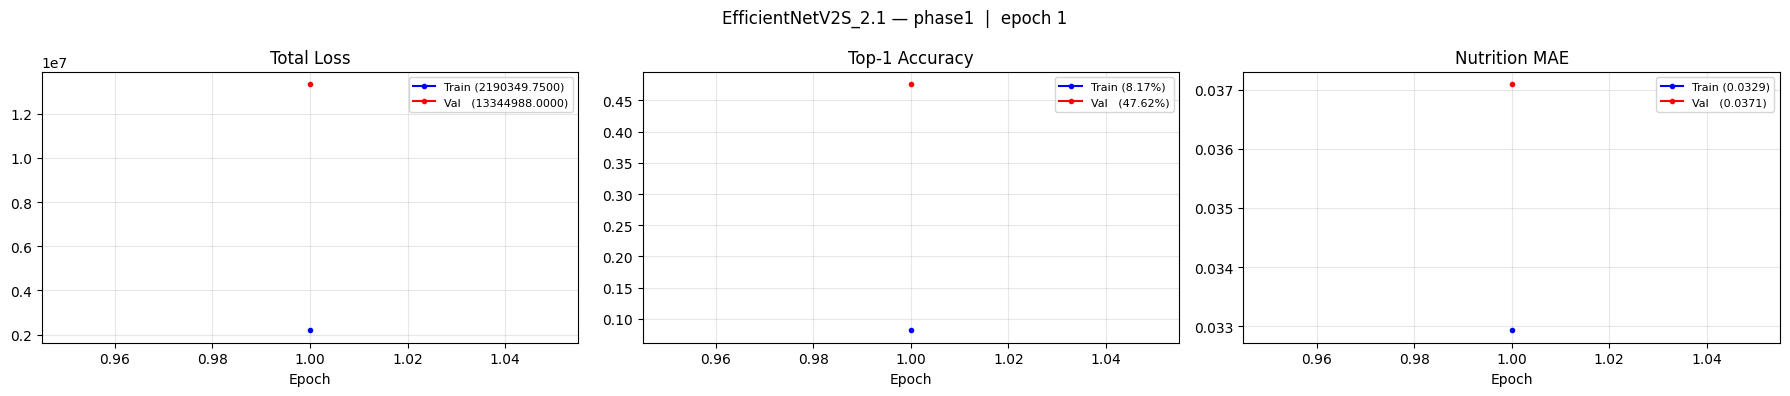

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 1489s 168ms/step - class_output_accuracy: 0.2394 - class_output_loss: 748668.8750 - class_output_top5_acc: 0.8314 - loss: 748747.6875 - nutrition_output_loss: 4.1141e-04 - nutrition_output_mae: 0.0418 - val_class_output_accuracy: 0.4762 - val_class_output_loss: 13343605.0000 - val_class_output_top5_acc: 0.9987 - val_loss: 13344988.0000 - val_nutrition_output_loss: 3.5014e-04 - val_nutrition_output_mae: 0.0371 - learning_rate: 0.0010
Epoch 2/60
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - class_output_accuracy: 0.1696 - class_output_loss: 40903568.0000 - class_output_top5_acc: 0.9999 - loss: 40905128.0000 - nutrition_output_loss: 5.5457e-04 - nutrition_output_mae: 0.0501  Epoch 2 time: 23.1 min  (1389s)


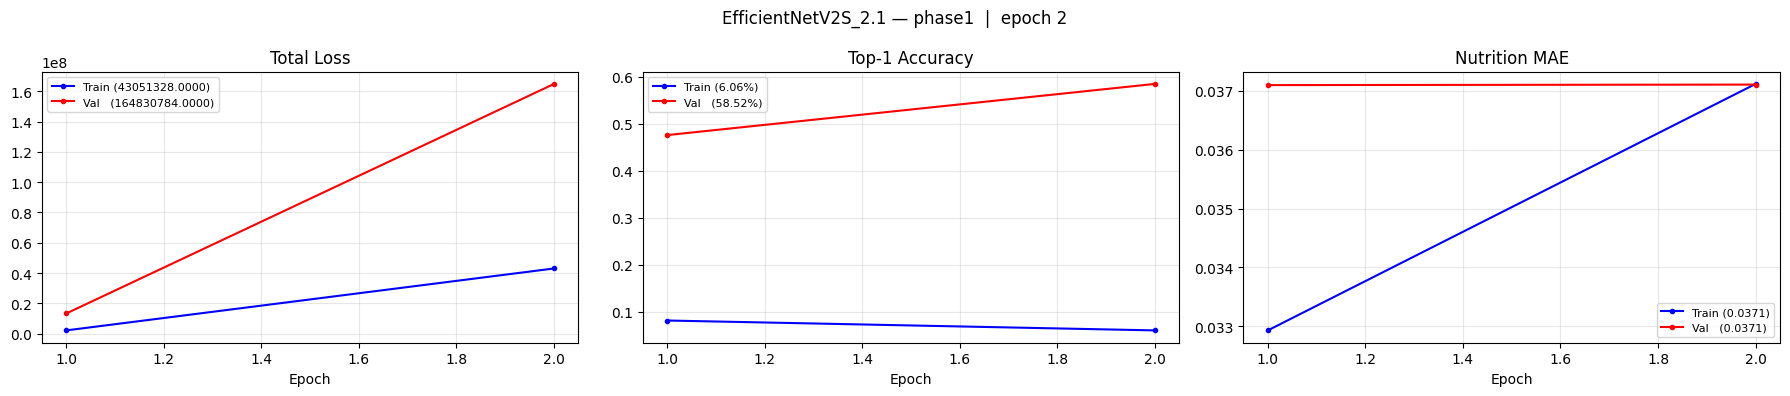

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 1389s 166ms/step - class_output_accuracy: 0.1696 - class_output_loss: 40903824.0000 - class_output_top5_acc: 0.9999 - loss: 40905384.0000 - nutrition_output_loss: 5.5455e-04 - nutrition_output_mae: 0.0501 - val_class_output_accuracy: 0.5852 - val_class_output_loss: 164821296.0000 - val_class_output_top5_acc: 0.9999 - val_loss: 164830784.0000 - val_nutrition_output_loss: 3.5023e-04 - val_nutrition_output_mae: 0.0371 - learning_rate: 0.0010
Epoch 3/60
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - class_output_accuracy: 0.1624 - class_output_loss: 254339120.0000 - class_output_top5_acc: 1.0000 - loss: 254344592.0000 - nutrition_output_loss: 5.5697e-04 - nutrition_output_mae: 0.0502  Epoch 3 time: 24.6 min  (1475s)


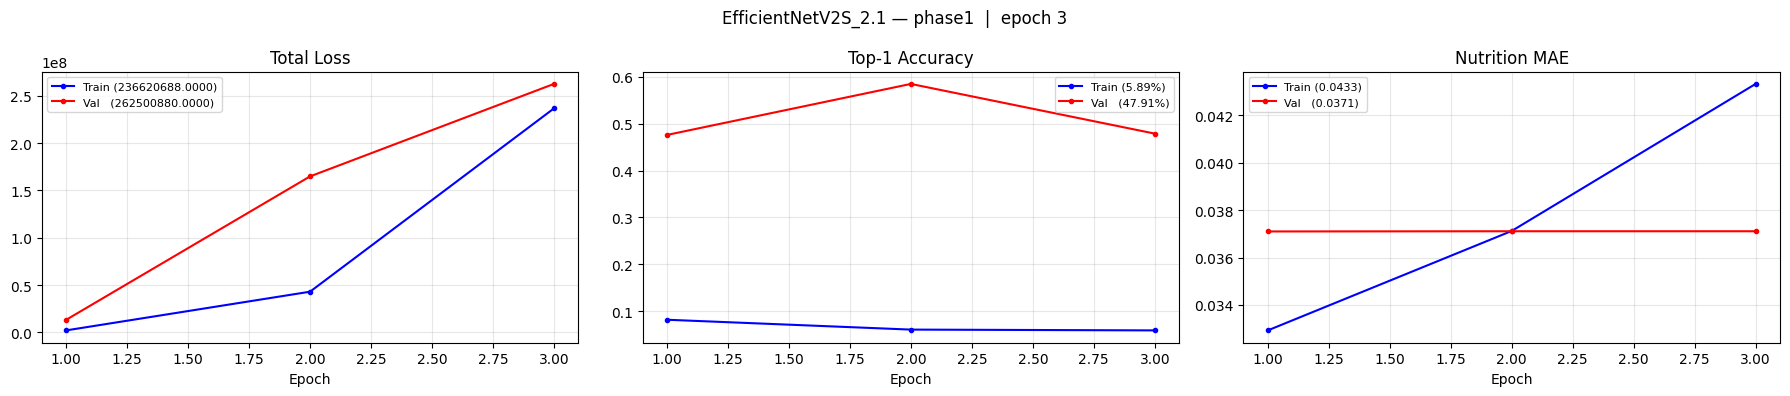

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 1476s 176ms/step - class_output_accuracy: 0.1624 - class_output_loss: 254336992.0000 - class_output_top5_acc: 1.0000 - loss: 254342464.0000 - nutrition_output_loss: 5.5696e-04 - nutrition_output_mae: 0.0502 - val_class_output_accuracy: 0.4791 - val_class_output_loss: 262491424.0000 - val_class_output_top5_acc: 0.9999 - val_loss: 262500880.0000 - val_nutrition_output_loss: 3.5025e-04 - val_nutrition_output_mae: 0.0371 - learning_rate: 0.0010
Epoch 4/60
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - class_output_accuracy: 0.1713 - class_output_loss: 820928448.0000 - class_output_top5_acc: 1.0000 - loss: 820940416.0000 - nutrition_output_loss: 5.5661e-04 - nutrition_output_mae: 0.0502  Epoch 4 time: 23.1 min  (1389s)


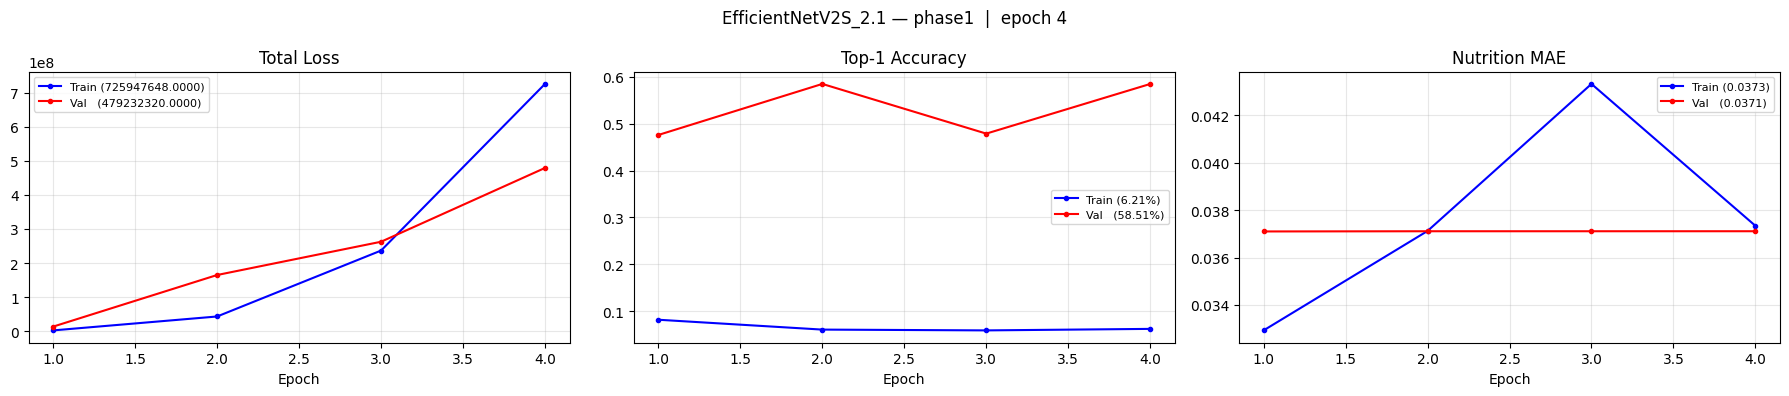

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 1389s 165ms/step - class_output_accuracy: 0.1713 - class_output_loss: 820917120.0000 - class_output_top5_acc: 1.0000 - loss: 820929088.0000 - nutrition_output_loss: 5.5658e-04 - nutrition_output_mae: 0.0502 - val_class_output_accuracy: 0.5851 - val_class_output_loss: 479247680.0000 - val_class_output_top5_acc: 1.0000 - val_loss: 479232320.0000 - val_nutrition_output_loss: 3.5025e-04 - val_nutrition_output_mae: 0.0371 - learning_rate: 0.0010
Epoch 5/60
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - class_output_accuracy: 0.1622 - class_output_loss: 1942337920.0000 - class_output_top5_acc: 1.0000 - loss: 1942359168.0000 - nutrition_output_loss: 0.0010 - nutrition_output_mae: 0.0702  Epoch 5 time: 22.9 min  (1373s)


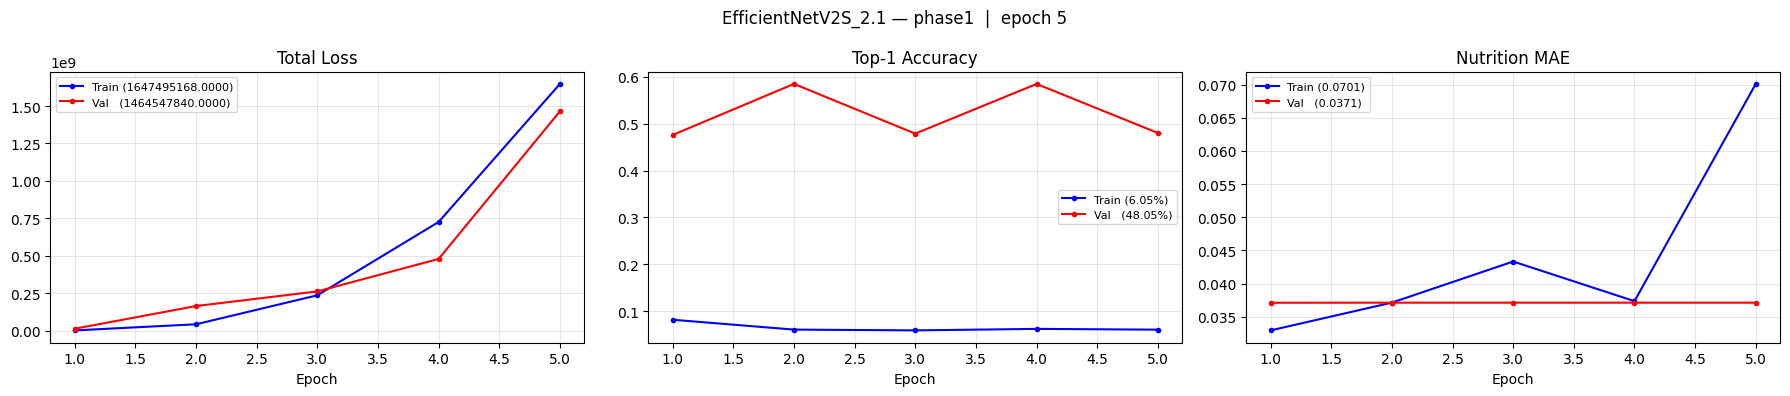

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 1374s 164ms/step - class_output_accuracy: 0.1621 - class_output_loss: 1942302720.0000 - class_output_top5_acc: 1.0000 - loss: 1942323968.0000 - nutrition_output_loss: 0.0010 - nutrition_output_mae: 0.0702 - val_class_output_accuracy: 0.4805 - val_class_output_loss: 1464494976.0000 - val_class_output_top5_acc: 0.9999 - val_loss: 1464547840.0000 - val_nutrition_output_loss: 3.5025e-04 - val_nutrition_output_mae: 0.0371 - learning_rate: 0.0010
Epoch 6/60
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - class_output_accuracy: 0.1797 - class_output_loss: 1311631488.0000 - class_output_top5_acc: 1.0000 - loss: 1311664512.0000 - nutrition_output_loss: 5.4940e-04 - nutrition_output_mae: 0.0499  Epoch 6 time: 23.0 min  (1378s)


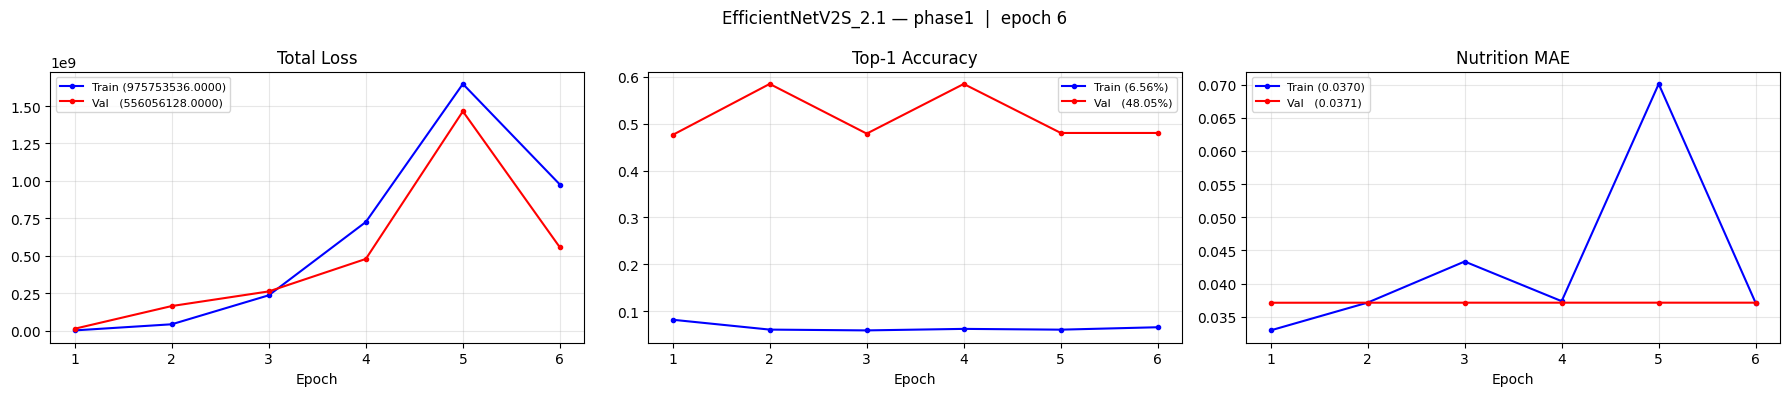

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 1379s 165ms/step - class_output_accuracy: 0.1797 - class_output_loss: 1311591296.0000 - class_output_top5_acc: 1.0000 - loss: 1311624448.0000 - nutrition_output_loss: 5.4937e-04 - nutrition_output_mae: 0.0499 - val_class_output_accuracy: 0.4805 - val_class_output_loss: 556019968.0000 - val_class_output_top5_acc: 1.0000 - val_loss: 556056128.0000 - val_nutrition_output_loss: 3.5025e-04 - val_nutrition_output_mae: 0.0371 - learning_rate: 3.0000e-04
Epoch 7/60
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - class_output_accuracy: 0.1678 - class_output_loss: 1429769600.0000 - class_output_top5_acc: 1.0000 - loss: 1429806336.0000 - nutrition_output_loss: 5.6321e-04 - nutrition_output_mae: 0.0504  Epoch 7 time: 23.0 min  (1380s)


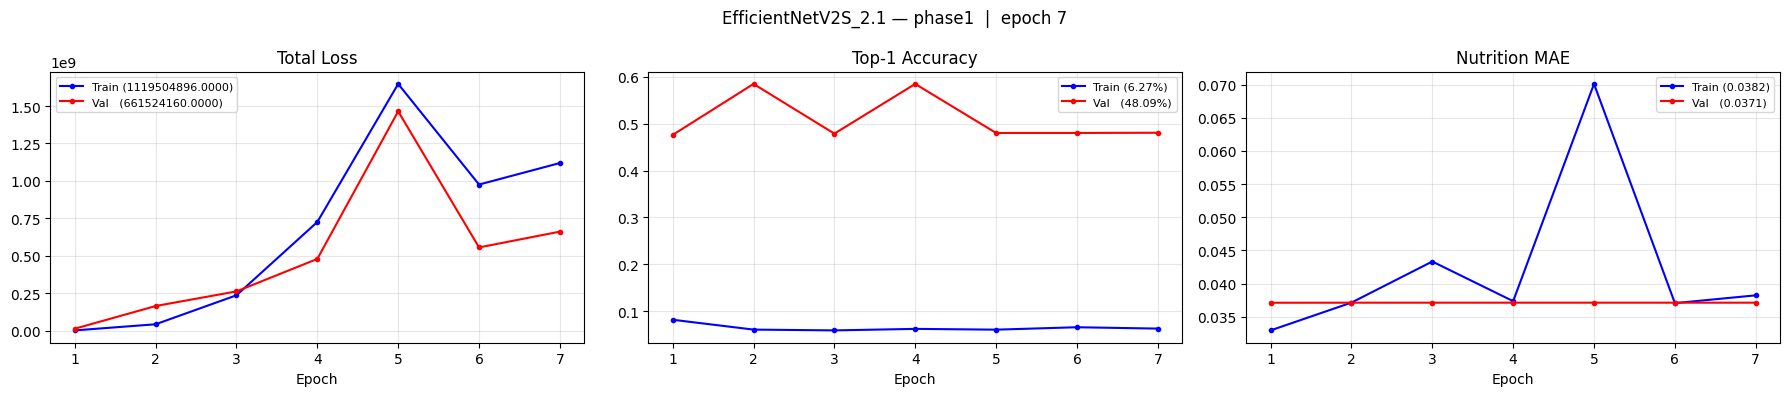

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 1381s 165ms/step - class_output_accuracy: 0.1678 - class_output_loss: 1429732608.0000 - class_output_top5_acc: 1.0000 - loss: 1429769344.0000 - nutrition_output_loss: 5.6319e-04 - nutrition_output_mae: 0.0504 - val_class_output_accuracy: 0.4809 - val_class_output_loss: 661489344.0000 - val_class_output_top5_acc: 0.9999 - val_loss: 661524160.0000 - val_nutrition_output_loss: 3.5025e-04 - val_nutrition_output_mae: 0.0371 - learning_rate: 3.0000e-04

Phase 1 total: 2.75h  (164.7min)
  Train cls acc (last): 6.27%
  Val   cls acc (last): 48.09%
  Best  val cls acc   : 58.52%
  Val   nut MAE (last): 0.0371
Saved phase 1 model.


In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss={
        'class_output':     keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        'nutrition_output': keras.losses.Huber(delta=0.1)
    },
    loss_weights={
        'class_output':     CLS_LOSS_WEIGHT,
        'nutrition_output': NUT_LOSS_WEIGHT
    },
    metrics={
        'class_output':     [
            'accuracy',
            tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')
        ],
        'nutrition_output': ['mae']
    }
)

save_model_info(model, SAVE_DIR)

# One full pass through training data per epoch (268039 // 32 = 8376)
STEPS_PER_EPOCH = len(train_paths) // BATCH_SIZE
print(f'Steps per epoch: {STEPS_PER_EPOCH}')

print('\n=== Phase 1: Head training ===')
ft_start = time.time()

history_ht = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=[
        ModelCheckpoint(
            f'{SAVE_DIR}/{MODEL_NAME}_best_base.keras',
            save_best_only=True,
            monitor='val_class_output_accuracy'
        ),
        EarlyStopping(
            patience=5,
            restore_best_weights=True,
            monitor='val_class_output_accuracy',
            mode='max'
        ),
        ReduceLROnPlateau(monitor='val_class_output_accuracy', factor=0.3, patience=3,
                  min_lr=1e-6, mode='max'),
        CSVLogger(f'{SAVE_DIR}/{MODEL_NAME}_history_base.log'),
        EpochTimer(),
        LivePlotCallback(SAVE_DIR, MODEL_NAME, phase='phase1'),
    ]
)

ft_total = time.time() - ft_start
h        = history_ht.history

print(f'\nPhase 1 total: {ft_total/3600:.2f}h  ({ft_total/60:.1f}min)')
print(f'  Train cls acc (last): {h["class_output_accuracy"][-1]*100:.2f}%')
print(f'  Val   cls acc (last): {h["val_class_output_accuracy"][-1]*100:.2f}%')
print(f'  Best  val cls acc   : {max(h["val_class_output_accuracy"])*100:.2f}%')
print(f'  Val   nut MAE (last): {h["val_nutrition_output_mae"][-1]:.4f}')

info_path = f'{SAVE_DIR}/{MODEL_NAME}_model_info.txt'
with open(info_path, 'a') as f:
    f.write(f'\n-- Phase 1 Results --\n')
    f.write(f'  Training time          : {ft_total/3600:.2f}h\n')
    f.write(f'  Train cls acc (last)   : {h["class_output_accuracy"][-1]*100:.2f}%\n')
    f.write(f'  Val   cls acc (last)   : {h["val_class_output_accuracy"][-1]*100:.2f}%\n')
    f.write(f'  Best  val cls acc      : {max(h["val_class_output_accuracy"])*100:.2f}%\n')
    f.write(f'  Val nut MAE (last)     : {h["val_nutrition_output_mae"][-1]:.4f}\n')

model.save(f'{SAVE_DIR}/{MODEL_NAME}_final_base.keras')
print('Saved phase 1 model.')

Trainable backbone layers: 250 / 513
Steps per epoch (phase 2): 8376

=== Phase 2: Fine-tuning ===
Epoch 1/20


E0000 00:00:1780232456.374539   65118 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780232456.655087   65118 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780232456.873481   65118 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-31 13:00:57.037385: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng3{k11=2} for conv (f32[32,960,24,24]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,960,26,26]{3,2,1,0}, f32[960,1,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, feature_group_count=960, custom_call_target="__cudnn$convForward", backend_config={"cudnn_conv_backend_config":{"activation_mod

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - class_output_accuracy: 0.1738 - class_output_loss: 93957512.0000 - class_output_top5_acc: 1.0000 - loss: 93961960.0000 - nutrition_output_loss: 5.9001e-04 - nutrition_output_mae: 0.0518  Epoch 1 time: 36.1 min  (2168s)


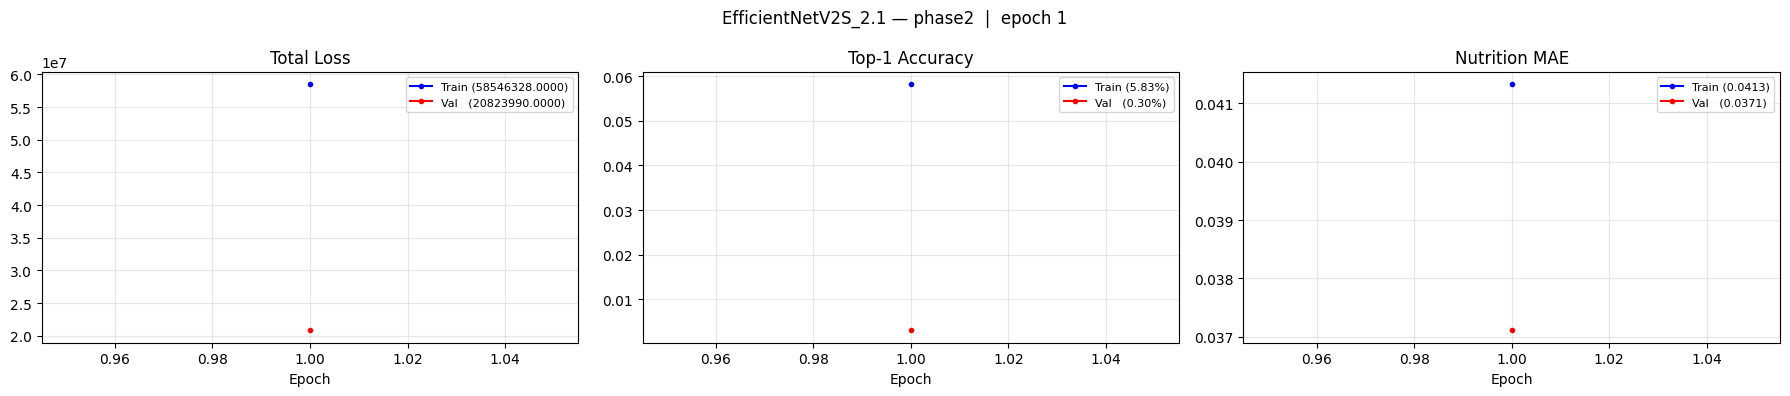

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 2168s 248ms/step - class_output_accuracy: 0.1737 - class_output_loss: 93953280.0000 - class_output_top5_acc: 1.0000 - loss: 93957736.0000 - nutrition_output_loss: 5.9000e-04 - nutrition_output_mae: 0.0518 - val_class_output_accuracy: 0.0030 - val_class_output_loss: 20815506.0000 - val_class_output_top5_acc: 1.0000 - val_loss: 20823990.0000 - val_nutrition_output_loss: 3.5026e-04 - val_nutrition_output_mae: 0.0371
Epoch 2/20
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - class_output_accuracy: 0.1276 - class_output_loss: 79899192.0000 - class_output_top5_acc: 1.0000 - loss: 79903712.0000 - nutrition_output_loss: 5.7209e-04 - nutrition_output_mae: 0.0509  Epoch 2 time: 34.2 min  (2053s)


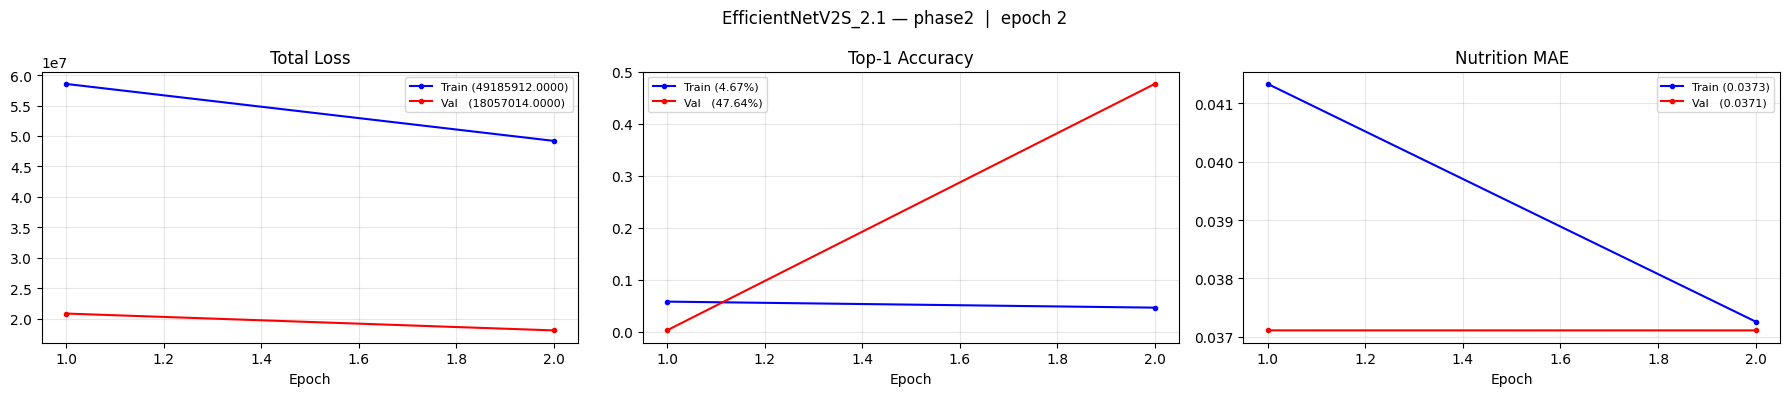

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 2054s 245ms/step - class_output_accuracy: 0.1276 - class_output_loss: 79895528.0000 - class_output_top5_acc: 1.0000 - loss: 79900048.0000 - nutrition_output_loss: 5.7206e-04 - nutrition_output_mae: 0.0509 - val_class_output_accuracy: 0.4764 - val_class_output_loss: 18050350.0000 - val_class_output_top5_acc: 1.0000 - val_loss: 18057014.0000 - val_nutrition_output_loss: 3.5026e-04 - val_nutrition_output_mae: 0.0371
Epoch 3/20
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - class_output_accuracy: 0.1231 - class_output_loss: 68049632.0000 - class_output_top5_acc: 1.0000 - loss: 68054304.0000 - nutrition_output_loss: 5.4990e-04 - nutrition_output_mae: 0.0499  Epoch 3 time: 34.2 min  (2054s)


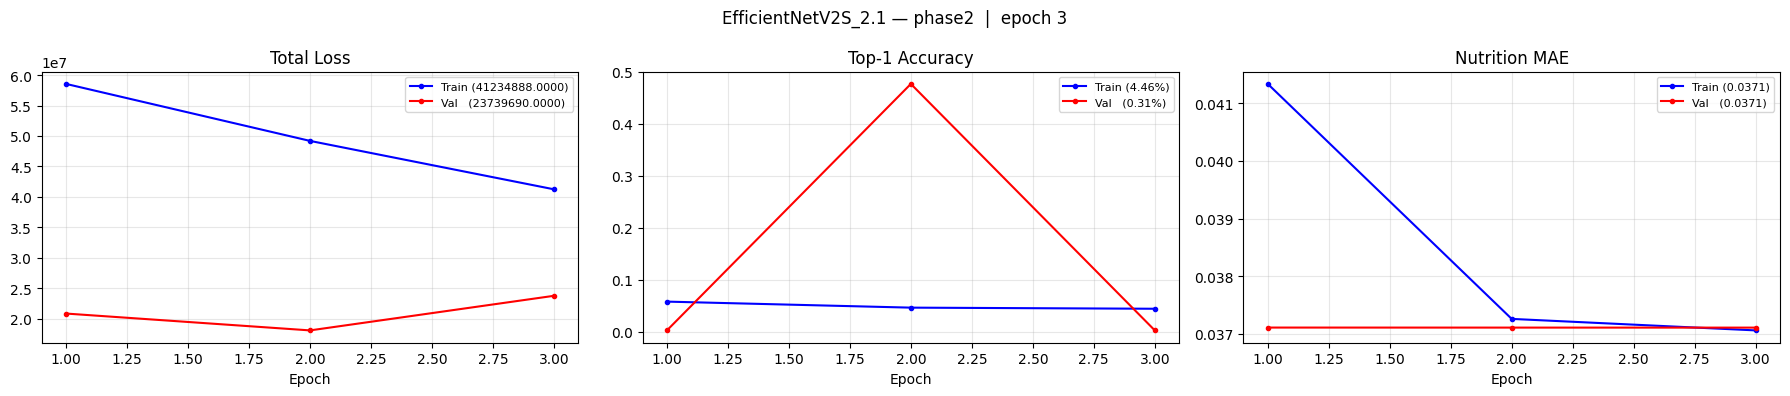

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 2055s 245ms/step - class_output_accuracy: 0.1231 - class_output_loss: 68046432.0000 - class_output_top5_acc: 1.0000 - loss: 68051104.0000 - nutrition_output_loss: 5.4987e-04 - nutrition_output_mae: 0.0499 - val_class_output_accuracy: 0.0031 - val_class_output_loss: 23730474.0000 - val_class_output_top5_acc: 1.0000 - val_loss: 23739690.0000 - val_nutrition_output_loss: 3.5026e-04 - val_nutrition_output_mae: 0.0371
Epoch 4/20
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - class_output_accuracy: 0.1357 - class_output_loss: 56064948.0000 - class_output_top5_acc: 1.0000 - loss: 56069652.0000 - nutrition_output_loss: 5.5399e-04 - nutrition_output_mae: 0.0501  Epoch 4 time: 34.2 min  (2052s)


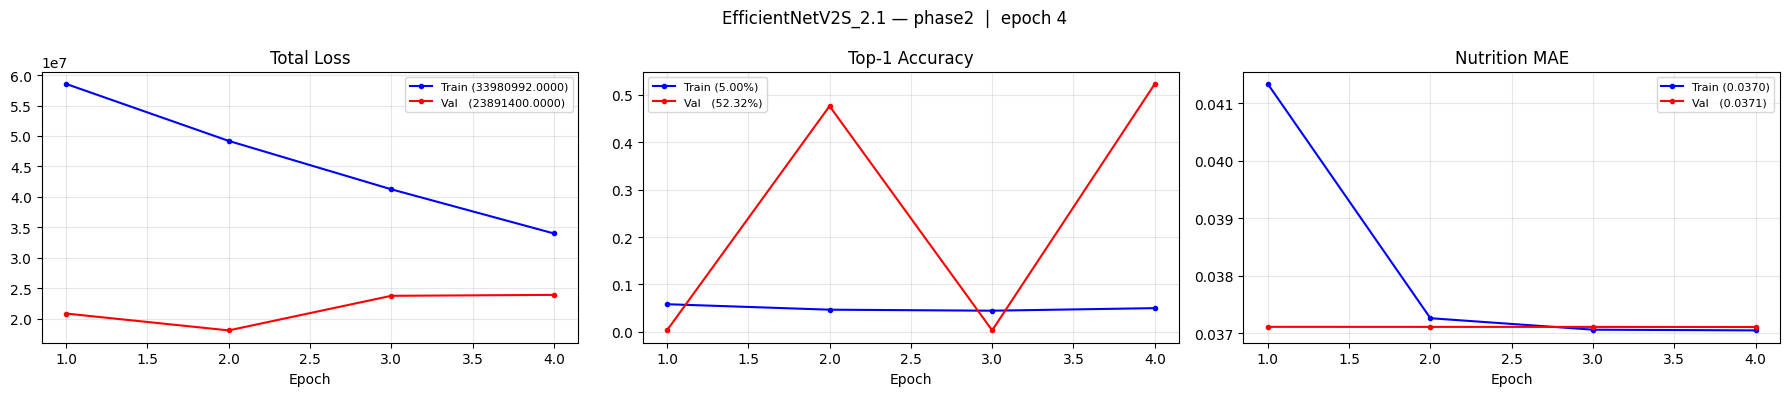

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 2052s 245ms/step - class_output_accuracy: 0.1356 - class_output_loss: 56062308.0000 - class_output_top5_acc: 1.0000 - loss: 56067012.0000 - nutrition_output_loss: 5.5396e-04 - nutrition_output_mae: 0.0501 - val_class_output_accuracy: 0.5232 - val_class_output_loss: 23883712.0000 - val_class_output_top5_acc: 1.0000 - val_loss: 23891400.0000 - val_nutrition_output_loss: 3.5022e-04 - val_nutrition_output_mae: 0.0371
Epoch 5/20
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - class_output_accuracy: 0.1217 - class_output_loss: 47967176.0000 - class_output_top5_acc: 1.0000 - loss: 47971876.0000 - nutrition_output_loss: 5.4971e-04 - nutrition_output_mae: 0.0499  Epoch 5 time: 34.2 min  (2052s)


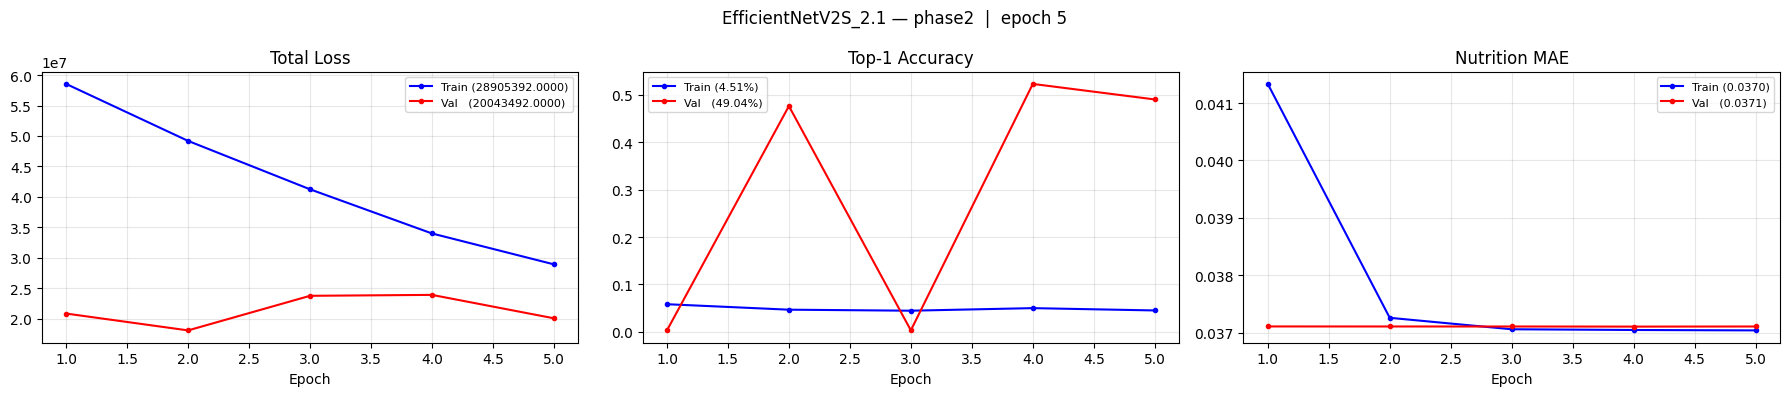

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 2052s 245ms/step - class_output_accuracy: 0.1217 - class_output_loss: 47964900.0000 - class_output_top5_acc: 1.0000 - loss: 47969600.0000 - nutrition_output_loss: 5.4969e-04 - nutrition_output_mae: 0.0499 - val_class_output_accuracy: 0.4904 - val_class_output_loss: 20036802.0000 - val_class_output_top5_acc: 1.0000 - val_loss: 20043492.0000 - val_nutrition_output_loss: 3.5026e-04 - val_nutrition_output_mae: 0.0371
Epoch 6/20
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - class_output_accuracy: 0.1250 - class_output_loss: 41318892.0000 - class_output_top5_acc: 1.0000 - loss: 41323668.0000 - nutrition_output_loss: 5.4867e-04 - nutrition_output_mae: 0.0498  Epoch 6 time: 34.7 min  (2081s)


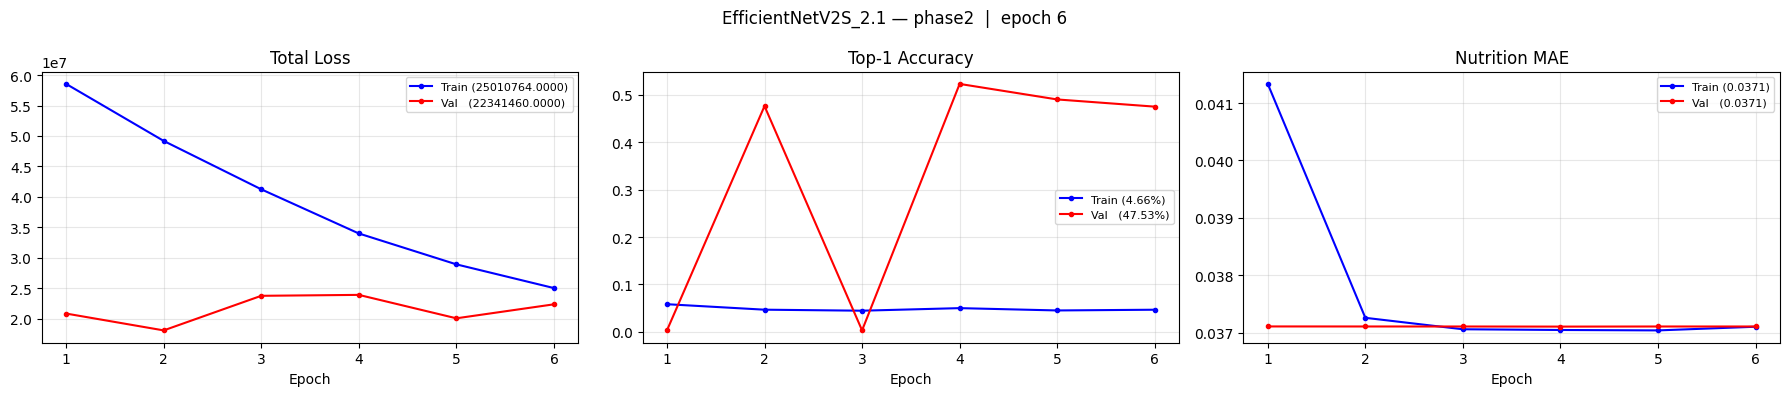

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 2082s 249ms/step - class_output_accuracy: 0.1250 - class_output_loss: 41316944.0000 - class_output_top5_acc: 1.0000 - loss: 41321720.0000 - nutrition_output_loss: 5.4865e-04 - nutrition_output_mae: 0.0498 - val_class_output_accuracy: 0.4753 - val_class_output_loss: 22335000.0000 - val_class_output_top5_acc: 1.0000 - val_loss: 22341460.0000 - val_nutrition_output_loss: 3.5026e-04 - val_nutrition_output_mae: 0.0371
Epoch 7/20
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - class_output_accuracy: 0.1410 - class_output_loss: 35083996.0000 - class_output_top5_acc: 1.0000 - loss: 35088792.0000 - nutrition_output_loss: 5.4973e-04 - nutrition_output_mae: 0.0499  Epoch 7 time: 35.4 min  (2122s)


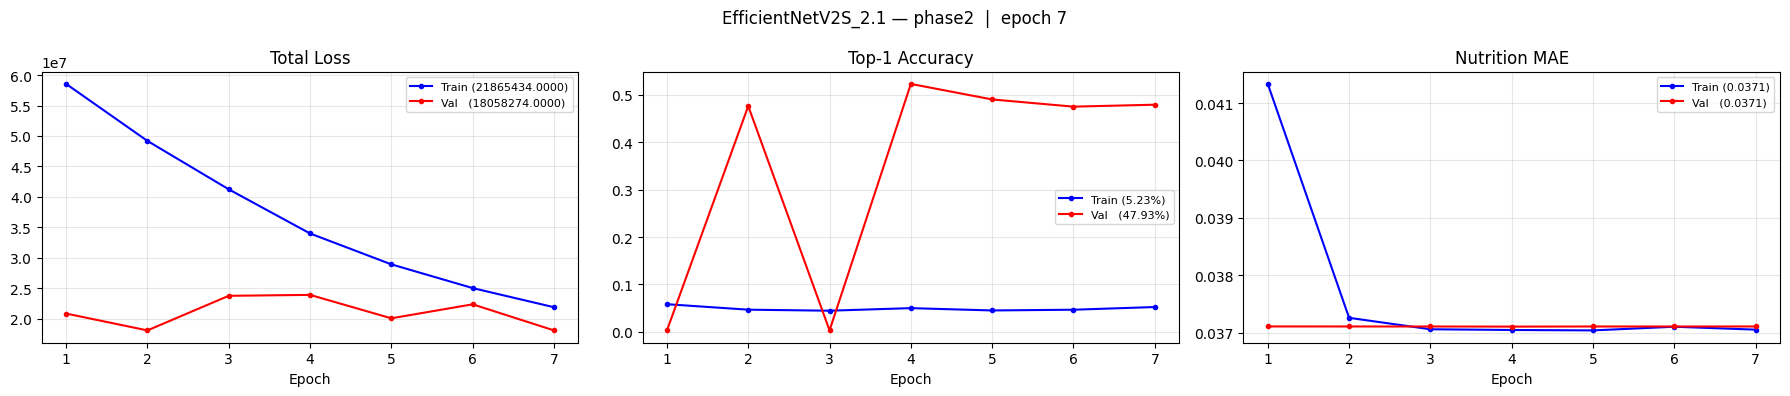

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 2122s 253ms/step - class_output_accuracy: 0.1410 - class_output_loss: 35082416.0000 - class_output_top5_acc: 1.0000 - loss: 35087216.0000 - nutrition_output_loss: 5.4971e-04 - nutrition_output_mae: 0.0499 - val_class_output_accuracy: 0.4793 - val_class_output_loss: 18052042.0000 - val_class_output_top5_acc: 1.0000 - val_loss: 18058274.0000 - val_nutrition_output_loss: 3.5026e-04 - val_nutrition_output_mae: 0.0371
Epoch 8/20
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - class_output_accuracy: 0.1279 - class_output_loss: 32661978.0000 - class_output_top5_acc: 1.0000 - loss: 32666818.0000 - nutrition_output_loss: 5.5168e-04 - nutrition_output_mae: 0.0499  Epoch 8 time: 35.4 min  (2122s)


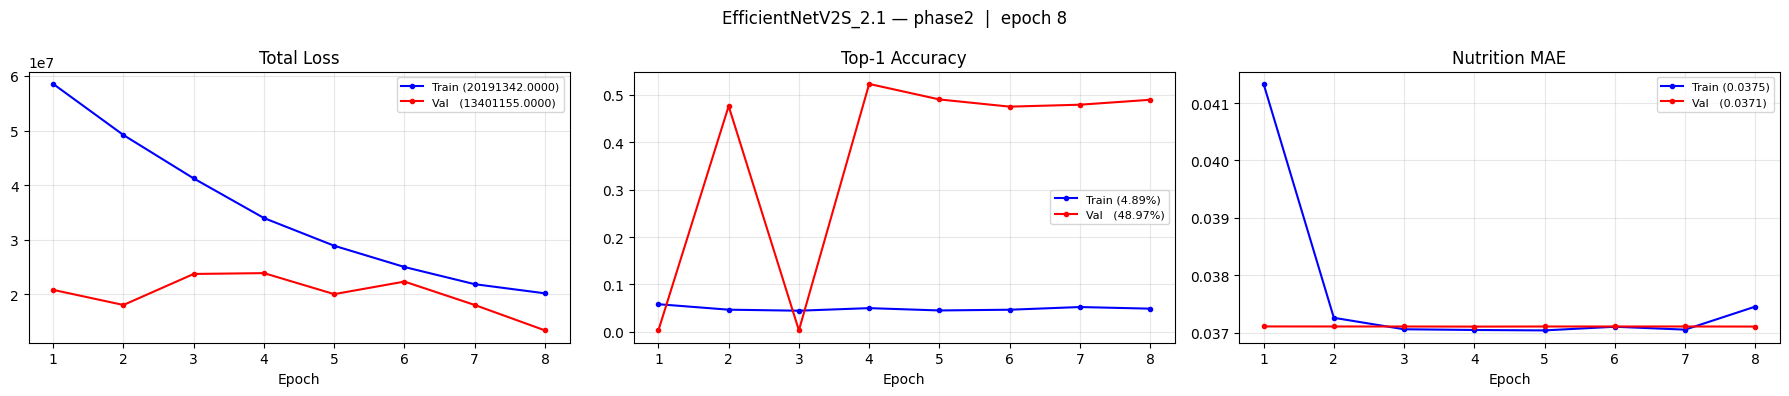

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 2124s 254ms/step - class_output_accuracy: 0.1279 - class_output_loss: 32660488.0000 - class_output_top5_acc: 1.0000 - loss: 32665330.0000 - nutrition_output_loss: 5.5166e-04 - nutrition_output_mae: 0.0499 - val_class_output_accuracy: 0.4897 - val_class_output_loss: 13395346.0000 - val_class_output_top5_acc: 0.9999 - val_loss: 13401155.0000 - val_nutrition_output_loss: 3.5024e-04 - val_nutrition_output_mae: 0.0371
Epoch 9/20
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - class_output_accuracy: 0.1295 - class_output_loss: 30241752.0000 - class_output_top5_acc: 1.0000 - loss: 30246648.0000 - nutrition_output_loss: 5.4734e-04 - nutrition_output_mae: 0.0497  Epoch 9 time: 35.5 min  (2128s)


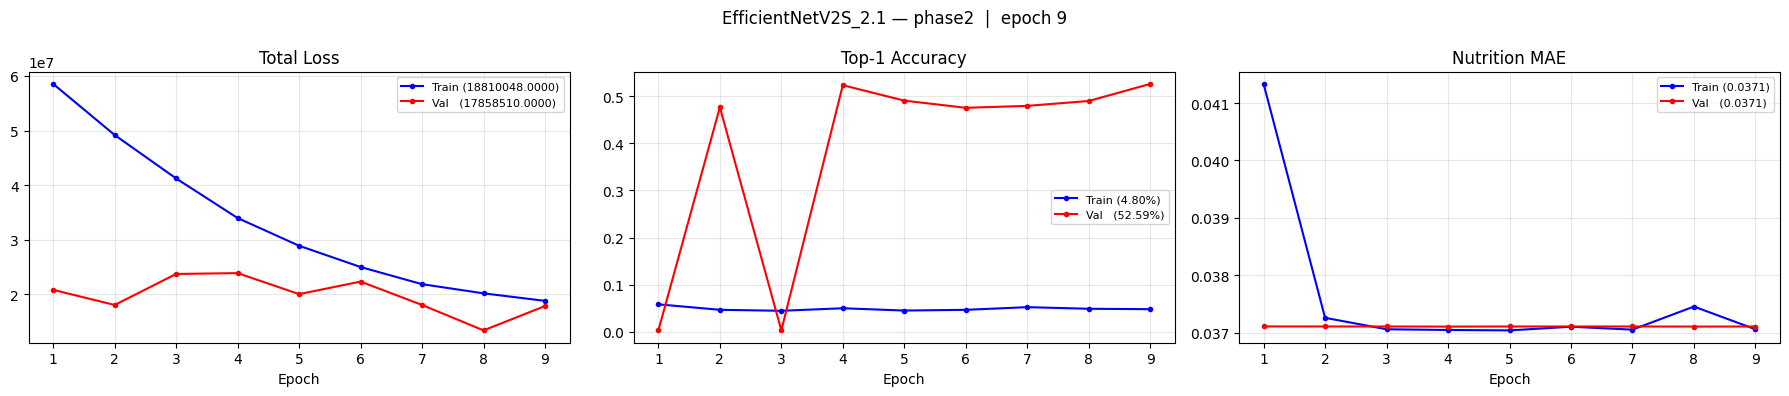

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 2129s 254ms/step - class_output_accuracy: 0.1295 - class_output_loss: 30240386.0000 - class_output_top5_acc: 1.0000 - loss: 30245284.0000 - nutrition_output_loss: 5.4732e-04 - nutrition_output_mae: 0.0497 - val_class_output_accuracy: 0.5259 - val_class_output_loss: 17852102.0000 - val_class_output_top5_acc: 1.0000 - val_loss: 17858510.0000 - val_nutrition_output_loss: 3.5026e-04 - val_nutrition_output_mae: 0.0371
Epoch 10/20
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - class_output_accuracy: 0.1470 - class_output_loss: 27252498.0000 - class_output_top5_acc: 1.0000 - loss: 27257428.0000 - nutrition_output_loss: 5.4816e-04 - nutrition_output_mae: 0.0498  Epoch 10 time: 35.5 min  (2132s)


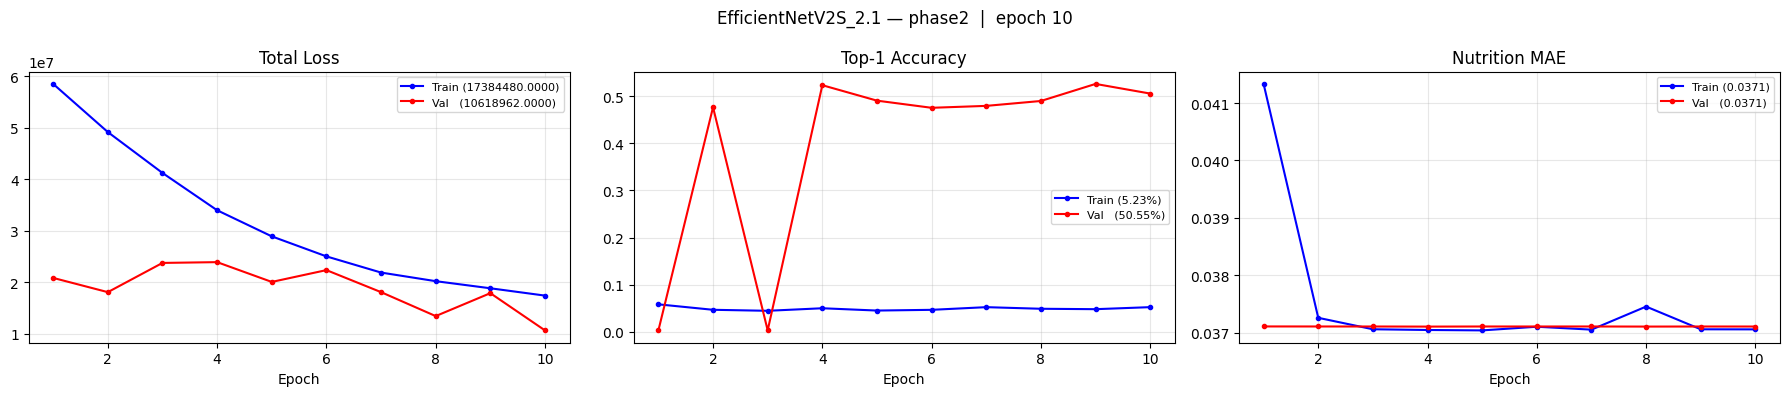

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 2132s 255ms/step - class_output_accuracy: 0.1470 - class_output_loss: 27251320.0000 - class_output_top5_acc: 1.0000 - loss: 27256250.0000 - nutrition_output_loss: 5.4814e-04 - nutrition_output_mae: 0.0498 - val_class_output_accuracy: 0.5055 - val_class_output_loss: 10612868.0000 - val_class_output_top5_acc: 0.9999 - val_loss: 10618962.0000 - val_nutrition_output_loss: 3.5025e-04 - val_nutrition_output_mae: 0.0371
Epoch 11/20
8376/8376 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - class_output_accuracy: 0.1502 - class_output_loss: 25459222.0000 - class_output_top5_acc: 1.0000 - loss: 25464166.0000 - nutrition_output_loss: 5.4904e-04 - nutrition_output_mae: 0.0498  Epoch 11 time: 35.4 min  (2124s)


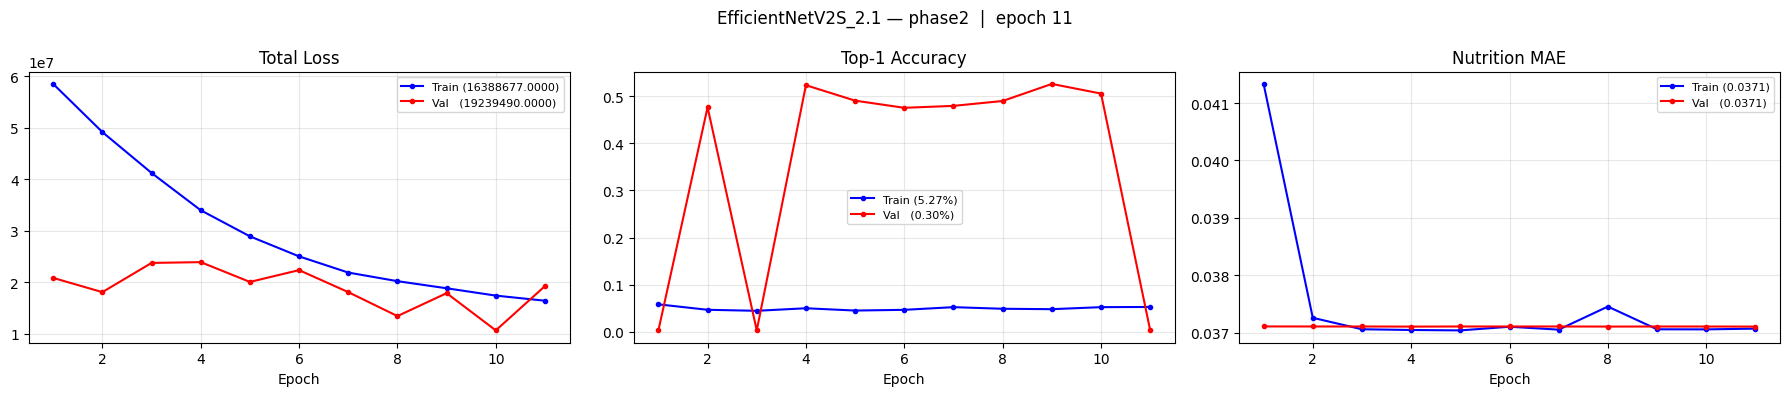

8376/8376 ━━━━━━━━━━━━━━━━━━━━ 2125s 254ms/step - class_output_accuracy: 0.1502 - class_output_loss: 25458140.0000 - class_output_top5_acc: 1.0000 - loss: 25463082.0000 - nutrition_output_loss: 5.4902e-04 - nutrition_output_mae: 0.0498 - val_class_output_accuracy: 0.0030 - val_class_output_loss: 19230682.0000 - val_class_output_top5_acc: 0.9999 - val_loss: 19239490.0000 - val_nutrition_output_loss: 3.5022e-04 - val_nutrition_output_mae: 0.0371
Epoch 12/20
6467/8376 ━━━━━━━━━━━━━━━━━━━━ 6:55 218ms/step - class_output_accuracy: 0.1619 - class_output_loss: 27870250.0000 - class_output_top5_acc: 1.0000 - loss: 27875200.0000 - nutrition_output_loss: 5.9546e-04 - nutrition_output_mae: 0.0527

In [ ]:
# -- Reload if kernel was restarted --
try:
    model
    base_model
except NameError:
    print(f'Reloading from {SAVE_DIR}/{MODEL_NAME}_final_base.keras ...')
    model      = keras.models.load_model(f'{SAVE_DIR}/{MODEL_NAME}_final_base.keras')
    base_model = next(l for l in model.layers if isinstance(l, tf.keras.Model))
    print(f'Loaded. base_model: {base_model.name}  ({len(base_model.layers)} layers)')

base_model.trainable = True

# -- Unfreeze from block 5 onward (layer 200+) for deeper food-specific adaptation --
for layer in base_model.layers[:200]:
    layer.trainable = False

# -- Keep BN in inference mode --
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable backbone layers: {trainable_count} / {len(base_model.layers)}')

# -- Reuse tiered dataset (already built) --
try:
    train_ds
    val_ds
except NameError:
    print('Rebuilding datasets...')
    train_ds = build_tiered_dataset(train_paths, train_labels, train_nuts)
    val_ds   = build_val_dataset(val_paths, val_labels, val_nuts)

steps_per_epoch = len(train_paths) // BATCH_SIZE
total_steps     = FINE_TUNE_EPOCHS * steps_per_epoch
print(f'Steps per epoch (phase 2): {steps_per_epoch}')

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=total_steps,
    alpha=1e-7
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss={
        'class_output':     keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        'nutrition_output': keras.losses.Huber(delta=0.1)
    },
    loss_weights={
        'class_output':     CLS_LOSS_WEIGHT,
        'nutrition_output': NUT_LOSS_WEIGHT
    },
    metrics={
        'class_output': [
            'accuracy',
            tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')
        ],
        'nutrition_output': ['mae']
    }
)

print('\n=== Phase 2: Fine-tuning ===')
ft_start = time.time()

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=[
        ModelCheckpoint(
            f'{SAVE_DIR}/{MODEL_NAME}_best_finetuned.keras',
            save_best_only=True,
            monitor='val_class_output_accuracy'
        ),
        EarlyStopping(
            patience=8,
            restore_best_weights=True,
            monitor='val_class_output_accuracy',
            mode='max'
        ),
        CSVLogger(f'{SAVE_DIR}/{MODEL_NAME}_history_finetuned.log'),
        EpochTimer(),
        LivePlotCallback(SAVE_DIR, MODEL_NAME, phase='phase2'),
    ]
)

ft_total = time.time() - ft_start
h        = history_ft.history

print(f'\nPhase 2 total: {ft_total/3600:.2f}h  ({ft_total/60:.1f}min)')
print(f'  Train cls acc (last): {h["class_output_accuracy"][-1]*100:.2f}%')
print(f'  Val   cls acc (last): {h["val_class_output_accuracy"][-1]*100:.2f}%')
print(f'  Best  val cls acc   : {max(h["val_class_output_accuracy"])*100:.2f}%')
print(f'  Val   nut MAE (last): {h["val_nutrition_output_mae"][-1]:.4f}')

info_path = f'{SAVE_DIR}/{MODEL_NAME}_model_info.txt'
with open(info_path, 'a') as f:
    f.write(f'\n-- Phase 2 Results --\n')
    f.write(f'  Fine-tune from layer   : 200+\n')
    f.write(f'  Training time          : {ft_total/3600:.2f}h\n')
    f.write(f'  Val   cls acc (last)   : {h["val_class_output_accuracy"][-1]*100:.2f}%\n')
    f.write(f'  Best  val cls acc      : {max(h["val_class_output_accuracy"])*100:.2f}%\n')
    f.write(f'  Val nut MAE (last)     : {h["val_nutrition_output_mae"][-1]:.4f}\n')

model.save(f'{SAVE_DIR}/{MODEL_NAME}_final.keras')
print('Saved final model.')

In [ ]:
try:
    history_ht
    history_ft
except NameError:
    H = lambda f: type('H', (), {'history': pd.read_csv(f).to_dict('list')})()
    history_ht = H(f'{SAVE_DIR}/{MODEL_NAME}_history_base.log')
    history_ft = H(f'{SAVE_DIR}/{MODEL_NAME}_history_finetuned.log')

def combine(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

n_ht = len(history_ht.history['class_output_accuracy'])
n_ft = len(history_ft.history['class_output_accuracy'])
all_epochs     = list(range(1, n_ht + n_ft + 1))
phase_boundary = n_ht

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'{MODEL_NAME} — Training Curves', fontsize=14)

def plot(ax, key, val_key, title):
    ax.plot(all_epochs, combine(history_ht, history_ft, key),     label='Train')
    ax.plot(all_epochs, combine(history_ht, history_ft, val_key), label='Val')
    ax.axvline(phase_boundary, color='gray', linestyle='--', label='Fine-tune start')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plot(axes[0,0], 'loss',                       'val_loss',                       'Total Loss')
plot(axes[0,1], 'class_output_accuracy',       'val_class_output_accuracy',       'Top-1 Accuracy')
plot(axes[1,0], 'class_output_top5_acc',       'val_class_output_top5_acc',       'Top-5 Accuracy')
plot(axes[1,1], 'nutrition_output_mae',        'val_nutrition_output_mae',        'Nutrition MAE (normalized)')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/{MODEL_NAME}_training_curves.png', dpi=150)
plt.show()
print(f'Saved → {SAVE_DIR}/{MODEL_NAME}_training_curves.png')

In [ ]:
try:
    model
except NameError:
    model = keras.models.load_model(f'{SAVE_DIR}/{MODEL_NAME}_final.keras')

print('Running inference on val set...')
y_true, y_pred, y_pred_probs_list = [], [], []

for images, targets in val_ds:
    cls_preds, _ = model.predict(images, verbose=0)
    y_true.extend(np.argmax(targets['class_output'].numpy(), axis=1))
    y_pred.extend(np.argmax(cls_preds, axis=1))
    y_pred_probs_list.extend(cls_preds)

y_true            = np.array(y_true)
y_pred            = np.array(y_pred)
y_pred_probs_arr  = np.array(y_pred_probs_list)

top1 = np.mean(y_true == y_pred) * 100
top5_hits = [y_true[i] in np.argsort(y_pred_probs_arr[i])[-5:] for i in range(len(y_true))]
top5 = np.mean(top5_hits) * 100

print(f'\n{"="*40}')
print(f'  Top-1 Accuracy : {top1:.2f}%')
print(f'  Top-5 Accuracy : {top5:.2f}%')
print(f'{"="*40}\n')

class_names  = [N_class[i] for i in range(N_CLASSES)]
report       = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
per_class_f1 = {cls: report[cls]['f1-score'] for cls in class_names}

worst20 = sorted(per_class_f1.items(), key=lambda x: x[1])[:20]
best20  = sorted(per_class_f1.items(), key=lambda x: x[1], reverse=True)[:20]

print('20 worst-performing classes (F1):')
for cls, f1 in worst20: print(f'  {cls:<35} F1={f1:.3f}')
print('\n20 best-performing classes (F1):')
for cls, f1 in best20:  print(f'  {cls:<35} F1={f1:.3f}')

In [ ]:
print('Running nutrition evaluation on val set...')
nut_true_list, nut_pred_list = [], []

for images, targets in val_ds:
    _, nut_preds = model.predict(images, verbose=0)
    nut_true_list.extend(targets['nutrition_output'].numpy())
    nut_pred_list.extend(nut_preds)

nut_true = np.array(nut_true_list)   # normalized [0,1]
nut_pred = np.array(nut_pred_list)

# Denormalize for human-readable MAE
nut_true_raw = denormalize_nutrition(nut_true)
nut_pred_raw = denormalize_nutrition(nut_pred)

print(f'\nNutrition MAE (raw units):')
for i, col in enumerate(NUT_COLS):
    mae = np.mean(np.abs(nut_true_raw[:, i] - nut_pred_raw[:, i]))
    print(f'  {col:<10}  MAE = {mae:.1f}')

In [ ]:
worst_indices = [class_names.index(c) for c, _ in worst20]
mask_worst    = np.isin(y_true, worst_indices)
cm_worst      = confusion_matrix(y_true[mask_worst], y_pred[mask_worst], labels=worst_indices)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_worst, annot=True, fmt='d', cmap='Reds',
            xticklabels=[class_names[i] for i in worst_indices],
            yticklabels=[class_names[i] for i in worst_indices])
plt.title(f'{MODEL_NAME} — Confusion Matrix (20 Worst Classes)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/{MODEL_NAME}_heatmap_worst.svg')
plt.show()

In [ ]:
primary_path  = f'{SAVE_DIR}/{MODEL_NAME}_final.keras'
fallback_path = f'{SAVE_DIR}/{MODEL_NAME}_best_finetuned.keras'

model_path = primary_path if os.path.exists(primary_path) else fallback_path
if not os.path.exists(model_path):
    raise FileNotFoundError('No trained model found — run training first')

model = tf.keras.models.load_model(model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Dynamic range quantization: ~4x smaller, minimal accuracy drop
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

tflite_path = f'{SAVE_DIR}/{MODEL_NAME}.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_path) / 1024 / 1024
print(f'TFLite saved → {tflite_path}')
print(f'File size    : {size_mb:.1f} MB')
print()
print('Files to ship with Android app:')
print(f'  {tflite_path}')
print(f'  output/label_map.json')
print(f'  output/class_to_fdcid.json')
print(f'  output/nutrition_stats.json')

# EfficientNetV2S 2.0 - Dual-Head (Classification + Nutrition)

**Changes from v1.1 (Food-101):**
- Dataset: Food-101 (101 classes) → MM-Food-100K + Fruits-360 (385 classes)
- Model output: single classification head → dual head (class + nutrition regression)
- Labels loaded from `label_map.json` instead of `classes.txt`
- tf.data pipeline reads from scanned directory + CSV nutrition lookup
- Loss: multi-task (CategoricalCrossentropy + Huber)
- Fixed `random_crop` bug from v1.1 (removed batch dim from size)

**Kept from v1.1:**
- Conv head architecture (1×1 bottleneck → 3×3 spatial → MaxPool → GAP)
- Phase 1 / Phase 2 training strategy
- EpochTimer, save_model_info, training curves, confusion matrix
- TFLite export